<a href="https://colab.research.google.com/github/sevval-345/SoftITo/blob/main/svm_analiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Veri seti bozuk satırlar ayıklanarak başarıyla yüklendi!
📊 Orijinal Veri Boyutu: 521850 satır, 12 sütun

⚖️ Veri seti başarıyla dengelendi ve SVM için optimize edildi!
🎯 Yeni Hedef Değişken Dağılımı:
Experience_Level
Fresher    10000
Junior     10000
Lead       10000
Senior     10000
Name: count, dtype: int64 



/tmp/ipykernel_2909/2784614037.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dengeli_df = df.groupby('Experience_Level', group_keys=False).apply(lambda x: x.sample(n=ornek_sayisi, random_state=42)).reset_index(drop=True)


⚖️ Özellikler normalleştirildi (StandardScaler).

🚀 SVM (RBF Kernel) Eğitimi Başlıyor (Yaklaşık 1-3 dakika sürebilir)...
✅ Model eğitimi başarıyla tamamlandı!

📊 DENGELİ SVM MODEL ACCURACY (DOĞRULUK): %44.24

📝 Sınıflandırma Raporu (Classification Report):
              precision    recall  f1-score   support

     Fresher       0.54      0.64      0.59      2500
      Junior       0.34      0.44      0.39      2500
        Lead       0.52      0.46      0.49      2500
      Senior       0.35      0.23      0.27      2500

    accuracy                           0.44     10000
   macro avg       0.44      0.44      0.43     10000
weighted avg       0.44      0.44      0.43     10000



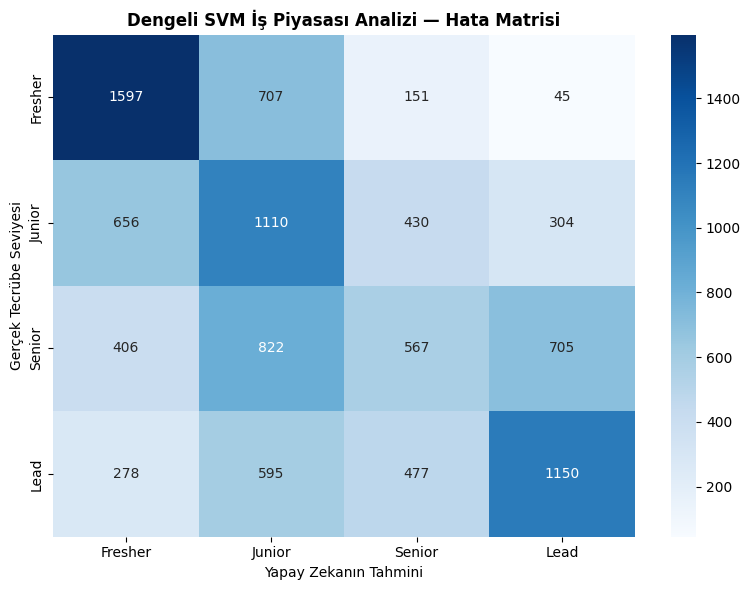

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==============================================================================
# 1. VERİ SETİNİ YÜKLEME VE TEMİZLEME (ParserError Çözümlü)
# ==============================================================================
data_path = "job_market_dataset.csv"

if not os.path.exists(data_path):
    print(f"❌ HATA: {data_path} dosyası bulunamadı! Lütfen sol panelden yüklediğinizden emin olun.")
else:
    # 'on_bad_lines='skip'' sayesinde bozuk satırlar elenir
    df = pd.read_csv(data_path, on_bad_lines='skip')
    print("✅ Veri seti bozuk satırlar ayıklanarak başarıyla yüklendi!")
    print(f"📊 Orijinal Veri Boyutu: {df.shape[0]} satır, {df.shape[1]} sütun\n")

    # ==============================================================================
    # 2. HEDEF DEĞİŞKENİ (Experience_Level) OLUŞTURMA
    # ==============================================================================
    # Deneyim yılına göre sınıfları kuruyoruz
    def kurala_gore_etiketle(yil):
        if yil <= 2: return 'Fresher'
        elif yil <= 5: return 'Junior'
        elif yil <= 10: return 'Senior'
        else: return 'Lead'

    df['Experience_Level'] = df['years_of_experience'].apply(kurala_gore_etiketle)

    # ==============================================================================
    # 3. VERİ DENGELEME VE BOYUT AZALTMA (DOWNSAMPLING)
    # ==============================================================================
    # Yarım milyon veri SVM'i kilitlemesin diye her gruptan 10k örnek seçiyoruz.
    # 'group_keys=False' ekleyerek Pandas'ın verdiği o kırmızı uyarı yazısını engelledik.
    ornek_sayisi = 10000
    dengeli_df = df.groupby('Experience_Level', group_keys=False).apply(lambda x: x.sample(n=ornek_sayisi, random_state=42)).reset_index(drop=True)

    print("⚖️ Veri seti başarıyla dengelendi ve SVM için optimize edildi!")
    print("🎯 Yeni Hedef Değişken Dağılımı:")
    print(dengeli_df['Experience_Level'].value_counts(), "\n")

    # ==============================================================================
    # 4. KATEGORİK VERİLERİ SAYISALA ÇEVİRME (Label Encoding)
    # ==============================================================================
    kategorik_sutunlar = ['country', 'occupation', 'field', 'employment_type', 'education_level', 'gender', 'company_size']
    le = LabelEncoder()

    for sutun in kategorik_sutunlar:
        dengeli_df[sutun] = le.fit_transform(dengeli_df[sutun].astype(str))

    # Modelin doğrudan kopya çekmesini engellemek için years_of_experience dışarıda bırakılır
    özellikler = ['country', 'occupation', 'field', 'salary', 'employment_type', 'education_level', 'gender', 'company_size']
    X = dengeli_df[özellikler]
    y = dengeli_df['Experience_Level']

    # ==============================================================================
    # 5. EĞİTİM VE TEST VERİSİ OLARAK BÖLME (Train-Test Split)
    # ==============================================================================
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

    # ==============================================================================
    # 6. VERİ ÖLÇEKLENDİRME (StandardScaler)
    # ==============================================================================
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("⚖️ Özellikler normalleştirildi (StandardScaler).")

    # ==============================================================================
    # 7. OPTİMİZE RBF SVM MODELİNİN EĞİTİLMESİ
    # ==============================================================================
    print("\n🚀 SVM (RBF Kernel) Eğitimi Başlıyor (Yaklaşık 1-3 dakika sürebilir)...")
    # Notebook dökümanındaki en başarılı doğrusal olmayan parametreler (C=100, gamma=0.01)
    svm_model = SVC(kernel='rbf', C=100, gamma=0.01, random_state=42)
    svm_model.fit(X_train_scaled, y_train)
    print("✅ Model eğitimi başarıyla tamamlandı!")

    # ==============================================================================
    # 8. TAHMİN ETME VE PERFORMANS RAPORLAMASI
    # ==============================================================================
    y_pred = svm_model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    print("\n" + "="*60)
    print(f"📊 DENGELİ SVM MODEL ACCURACY (DOĞRULUK): %{accuracy*100:.2f}")
    print("="*60)

    print("\n📝 Sınıflandırma Raporu (Classification Report):")
    print(classification_report(y_test, y_pred))

    # ==============================================================================
    # 9. HATA MATRİSİ (Confusion Matrix) GÖRSELLEŞTİRME
    # ==============================================================================
    sinif_siralamasi = ['Fresher', 'Junior', 'Senior', 'Lead']
    cm = confusion_matrix(y_test, y_pred, labels=sinif_siralamasi)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sinif_siralamasi,
                yticklabels=sinif_siralamasi)

    plt.title('Dengeli SVM İş Piyasası Analizi — Hata Matrisi', fontsize=12, fontweight='bold')
    plt.ylabel('Gerçek Tecrübe Seviyesi')
    plt.xlabel('Yapay Zekanın Tahmini')
    plt.tight_layout()
    plt.show()